<div align="center">

# **DS102: BÀI THỰC HÀNH SỐ 02**
**Họ và tên: Phạm Đình Quang Huy**

**MSSV: 24520689**  
</div>

## **I. Giới thiệu**
- Bài thực hành số 02 với mục đích giúp định hình và xây dựng mô hình phân loại nhị phân `Logistic Regression` và phân loại đa lớp `Softmax Regression`. Sau đó áp dụng phân loại sinh viên `Dropout`, `Graduate`, `Enrolled` trên bộ dữ liệu `Predict Students' Dropout and Academic Success`.

- Đồng thời, giúp sinh viên biết cách tổ chức thành các class để có thể tái sử dụng:
    + Class PreProcessing.
    + Class Logistic Regresion.
    + Class Softmax Regresion.
    + Gọi các hàm để thực hiện spliting, encoding và scaling data.
    + Vẽ biểu đồ thể hiện accuracy.
    + Kết luận.

- Bộ dữ liệu `Predict Students' Dropout and Academic Success` được lấy UC Irvine Machine Learning Repository với hơn 36 thuộc tính và 1 biến target.

## **II. Tiền xử lí dữ liệu**

### **2.1. Import library**
- `numpy` dùng để tính toán trên ma trận.
- `pandas` dùng để thao tác trên DataFrame.
- `matplotlib.pyplot` và `seaborn` dùng để minh họa quá trình thông qua biểu đồ.

In [734]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### **2.2. Define class preprocessing**

Đóng gói các `@staticmethod` để dễ dàng sử dụng cho những lần sau, làm tăng khả năng sử dụng lại code, tránh lãng phí thời gian.

Định nghĩa các hàm với chức năng như sau:
- `target_encoder_logistic` là hàm để mã hóa nhãn của cột Target thành các giá trị 0 và 1 sử dụng cho mô hình Logistic Regression.
    + Nhãn 'Dropout' và 'Enrolled' thành 1
    + Nhãn 'Graduate' thành 0.
- `target_encoder_softmax` là hàm để mã hóa các giá trị của cột Target bằng cách tạo các cột `Graduate`, `Dropout` và `Enrolled`, sử dụng trong mô hình Softmax Regression from scratch.

- `label_encoder` là hàm dùng để mã hóa nhãn của cột Target thành các giá trị 0, 1, 2 sử dụng cho mô hình Softmax Regression from sklearn.

- `split_train_test` là hàm dùng để chia dữ liệu thành training set và test set.
    + df: DataFrame cần chia dữ liệu.
    + test_size: độ lớn của test set.
    + random_state: dùng để chia ngẫu nhiên dữ liệu.
- `scale_features` là hàm để chuẩn hóa dữ liệu theo phân phối chuẩn.


In [735]:
class preprocessing:
    @staticmethod
    def target_encoder_logistic(value: str) -> int:
        if value in ['Dropout', 'Enrolled']:
            return 1
        return 0
    
    @staticmethod
    def target_encoder_softmax(df: pd.DataFrame, target: str) -> pd.DataFrame:
        feature = ['Graduate', 'Enrolled', 'Dropout']
        
        encode = df.copy()
        for value in feature:
            encode[value] = (encode[target] == value).astype(int)
        
        encode = encode.drop(columns=target)
        return encode
    
    @staticmethod
    def label_encoder(df: pd.DataFrame, target_column):
        classes = np.unique(df[target_column])

        encoded_label = df.copy()
        mapping = {
            label: i for i, label in enumerate(classes)
        }

        encoded_label[target_column] = encoded_label[target_column].map(mapping).values

        return encoded_label, mapping
    
    @staticmethod
    def split_train_test(df: pd.DataFrame, test_size: float, random_state: int):
        if random_state:
            np.random.seed(random_state)
            
        shuffer_indices = np.random.permutation(len(df))
        test_set_size = int(len(df) * test_size)

        test_indices = shuffer_indices[:test_set_size]
        train_indices = shuffer_indices[test_set_size:]
        
        return df.iloc[train_indices], df.iloc[test_indices]
    
    @staticmethod
    def scale_features(X: np.ndarray):
        mean = np.mean(X, axis=0)
        std = np.std(X, axis=0)
        std[std == 0] = 1 
        X_scaled = (X - mean) / std
        return X_scaled, mean, std

### **2.3. Read data and split into test/training set**
***Lưu ý:*** Dữ liệu sẽ được chia thành traning set và test set trước và sau đó sẽ áp dụng encoding và scaler để dữ liệu không bị khác nhau khi chạy các chương trình.

In [736]:
df = pd.read_csv('data.csv', sep=';')
pre = preprocessing()
train, test = pre.split_train_test(df, test_size=0.2, random_state=42)

continuous_features = ['Previous qualification (grade)',
                       'Admission grade',
                       'Unemployment rate',
                       'Inflation rate',
                       'GDP',
                       'Age at enrollment',
                       ]

remove_columns = ['Course',
                  "Mother's occupation",
                  "Father's occupation",]

train[continuous_features], mean_train, std_train = pre.scale_features(train[continuous_features])
test[continuous_features] = (test[continuous_features] - mean_train) / std_train

train = train.drop(columns=remove_columns)
test = test.drop(columns=remove_columns)

In [737]:
pd.set_option('display.max_columns', None)
train.describe()

,Marital status,Application mode,Application order,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,Admission grade,Displaced,Educational special needs,Debtor,Tuition fees up to date,Gender,Scholarship holder,Age at enrollment,International,Curricular units 1st sem (credited),Curricular units 1st sem (enrolled),Curricular units 1st sem (evaluations),Curricular units 1st sem (approved),Curricular units 1st sem (grade),Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP
count,3540.000000,3540.000000,3540.000000,3540.000000,3540.000000,3.540000e+03,3540.000000,3540.000000,3540.000000,3.540000e+03,3540.000000,3540.000000,3540.000000,3540.000000,3540.000000,3540.000000,3.540000e+03,3540.000000,3540.000000,3540.000000,3540.000000,3540.000000,3540.000000,3540.000000,3540.000000,3540.000000,3540.000000,3540.000000,3540.000000,3540.000000,3.540000e+03,3.540000e+03,3.540000e+03
mean,1.174576,18.739266,1.735311,0.886158,4.457627,1.422089e-15,1.840395,19.364972,22.338983,-9.433759e-17,0.547458,0.011299,0.113559,0.883051,0.356215,0.253955,-1.746249e-16,0.024576,0.683333,6.221186,8.248305,4.694068,10.627152,0.131921,0.524576,6.181921,8.021469,4.428814,10.228521,0.144915,1.124022e-16,-2.007183e-17,3.211493e-17
std,0.592434,17.440768,1.318354,0.317664,10.058190,1.000141e+00,6.710727,15.574833,15.324789,1.000141e+00,0.497813,0.105711,0.317320,0.321405,0.478947,0.435334,1.000141e+00,0.154852,2.274719,2.464659,4.201506,3.064793,4.848246,0.678536,1.858278,2.187511,3.954115,2.983001,5.212215,0.738988,1.000141e+00,1.000141e+00,1.000141e+00
min,1.000000,1.000000,0.000000,0.000000,1.000000,-2.844477e+00,1.000000,1.000000,1.000000,-2.199417e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-8.352365e-01,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-1.485134e+00,-1.476731e+00,-1.790459e+00
25%,1.000000,1.000000,1.000000,1.000000,1.000000,-5.780328e-01,1.000000,2.000000,3.000000,-6.250079e-01,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,-5.659158e-01,0.000000,0.000000,5.000000,6.000000,3.000000,11.000000,0.000000,0.000000,5.000000,6.000000,2.000000,10.800000,0.000000,-8.105782e-01,-6.790074e-01,-7.521055e-01
50%,1.000000,17.000000,1.000000,1.000000,1.000000,3.390702e-02,1.000000,19.000000,19.000000,-5.186780e-02,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,-4.312555e-01,0.000000,0.000000,6.000000,8.000000,5.000000,12.326032,0.000000,0.000000,6.000000,8.000000,5.000000,12.200000,0.000000,-1.734980e-01,1.187162e-01,1.366549e-01
75%,1.000000,39.000000,2.000000,1.000000,1.000000,5.551891e-01,1.000000,37.000000,37.000000,5.419882e-01,1.000000,0.000000,0.000000,1.000000,1.000000,1.000000,2.420463e-01,0.000000,0.000000,7.000000,10.000000,6.000000,13.400000,0.000000,0.000000,7.000000,10.000000,6.000000,13.333333,0.000000,8.758107e-01,9.889600e-01,7.834261e-01
max,6.000000,57.000000,9.000000,1.000000,43.000000,4.332596e+00,109.000000,43.000000,44.000000,4.360621e+00,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,6.301762e+00,1.000000,20.000000,26.000000,45.000000,26.000000,18.875000,12.000000,18.000000,23.000000,33.000000,20.000000,18.571429,12.000000,1.737743e+00,1.786684e+00,1.540192e+00


## **III. Phần thực hành**

### **1. Assignment 1 (4 scores):**

- Use Numpy only to construct the Logistic Regression model.
- Train that Logistic Regression model dataset using the Gradient Descent approach on the [Predict students’ dropout and academic success](https://archive.ics.uci.edu/dataset/697/predict+students+dropout+and+academic+success) dataset. *Note that three class in this dataset must be merge into two class as: graduate and non-graduate (dropout or enroll)*.
- Evaluate that Logistic Regression model on the [Predict students’ dropout and academic success](https://archive.ics.uci.edu/dataset/697/predict+students+dropout+and+academic+success) dataset.
- Visualize the loss function of the training process.

#### ***1.1 Define logistic regression***

In [738]:
class logistic:
    def __init__(self, lr: float = 0.01, epochs: int = 1000):
        ''' 
        Hàm này dùng để khởi tạo các biến cho mô hình
        Bao gồm: 
            - lr: learning rate
            - epochs: số lượng vòng lặp
            - weight: weight của mô hình
            - bias: bias của mô hình
            - acc_his: dùng để lưu trữ accuracy theo thời gian
            - loss_his: dùng để lưu trữ lại loss theo thời gian
        '''
        self.lr = lr
        self.epochs = epochs
        self.weight = None
        self.bias = None
        self.acc_his = []
        self.loss_his = []

    @staticmethod
    def sigmoid(z: np.ndarray) -> np.ndarray:
        ''' 
        Hàm này sử dụng để tính xác suất bằng hàm sigmoid và 
        đã giới hạn giá trị của z để tránh overflow khi tính exp
        '''
        z = np.clip(z, -500, 500)
        return 1 / (1 + np.exp(-z))

    def fit(self, X: np.ndarray, y: np.ndarray):
        ''' 
        Hàm này được sử dụng để training mô hình và update các thông số
        của mô hình sau các epoch. 
        Sử dụng Gradient Descent update trọng số.
        Sau đó, tính accuracy và loss rồi lưu vào loss_his và acc_his
        '''
        self.weight = np.zeros(X.shape[1])
        self.bias = 0

        for epoch in range(self.epochs):
            z = X @ self.weight + self.bias
            y_pred = self.sigmoid(z)

            dw = (1 / X.shape[0]) * (X.T @ (y_pred - y))
            db = (1 / X.shape[0]) * np.sum(y_pred - y)

            self.weight -= self.lr * dw
            self.bias -= self.lr * db
            
            loss = self.loss_function(y, y_pred)
            acc = self.accuracy(y, self.predict(X))

            self.loss_his.append(loss)
            self.acc_his.append(acc)
            
    def loss_function(self, y: np.ndarray, y_hat: np.ndarray) -> float:
        y_hat = np.clip(y_hat, 1e-15, 1 - 1e-15)
        return -np.mean(y * np.log(y_hat) + (1 - y) * np.log(1 - y_hat))
    
    def predict_proba(self, X: np.ndarray) -> np.ndarray:
        z = X @ self.weight + self.bias
        return self.sigmoid(z)

    def predict(self, X: np.ndarray) -> np.ndarray:
        return (self.predict_proba(X) >= 0.5).astype(int)

    @staticmethod
    def accuracy(y_true: np.ndarray, y_pred: np.ndarray) -> float:
        return np.mean(y_true == y_pred)

#### ***1.2. Encoding, splitting and scaling data***

In [739]:
train_lr, test_lr = train.copy(), test.copy()

train_lr['Target'] = train_lr['Target'].apply(pre.target_encoder_logistic)
test_lr['Target'] = test_lr['Target'].apply(pre.target_encoder_logistic)

X_train_lr = train_lr.iloc[:, :-1].values
y_train_lr = train_lr.iloc[:, -1].values

X_test_lr = test_lr.iloc[:, :-1].values
y_test_lr = test_lr.iloc[:, -1].values

#### ***1.3. Training model and calculate accuracy***

In [740]:
logistic_model = logistic(lr=0.001, epochs=1000)
logistic_model.fit(X_train_lr, y_train_lr)

pred_lr = logistic_model.predict(X_test_lr)
accuracy_lr = logistic_model.accuracy(y_test_lr, pred_lr)

print(f"Test Accuracy của Logistic Regression from Scratch: {accuracy_lr * 100:.4f}%")

Test Accuracy của Logistic Regression from Scratch: 79.8643%


#### ***1.4. Visualize accuracy by epochs***

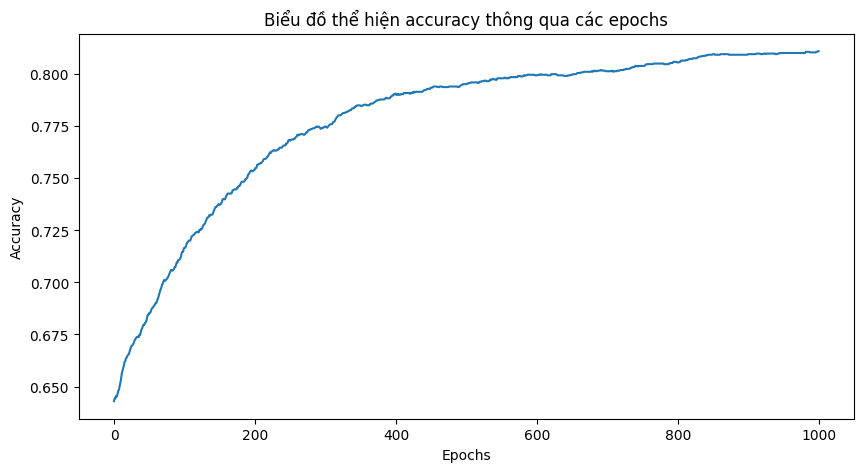

In [741]:
plt.figure(figsize=(10, 5))
plt.plot(logistic_model.acc_his)
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Biểu đồ thể hiện accuracy thông qua các epochs')
plt.show()

#### ***1.5 Visualize loss function by epochs***

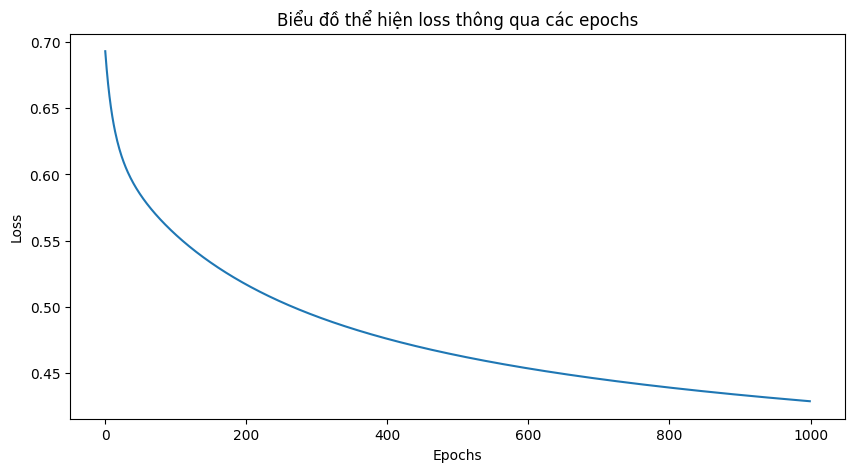

In [742]:
plt.figure(figsize=(10, 5))
plt.plot(logistic_model.loss_his)
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Biểu đồ thể hiện loss thông qua các epochs')
plt.show()

### **2. Assignment 2 (4 scores):**

- Use Numpy only to construct the Sofmax Regression model.
- Train that Logistic Regression model dataset using the Gradient Descent approach on the [Predict students’ dropout and academic success](https://archive.ics.uci.edu/dataset/697/predict+students+dropout+and+academic+success) dataset.
- Evaluate that Logistic Regression model on the [Predict students’ dropout and academic success](https://archive.ics.uci.edu/dataset/697/predict+students+dropout+and+academic+success) dataset.
- Visualize the loss function of the training process.

#### ***2.1. Define the Softmax Regression***

In [743]:
class SoftmaxRegression:
    def __init__(self, epochs: int = 1000, lr: float = 0.01):
        '''
        Hàm này dùng để khởi tạo các tham số cho mô hình Softmax Regression
        Bao gồm:
            - epochs: số lượng vòng lặp
            - lr: learning rate
            - weight: weight của mô hình
            - bias: bias của mô hình
            - acc_his: dùng để lưu trữ accuracy theo thời gian
            - loss_his: dùng để lưu trữ lại loss theo thời gian
        '''
        self.epochs = epochs
        self.lr = lr
        self.weight = None
        self.bias = None
        self.acc_his = []
        self.loss_his = []

    @staticmethod
    def softmax(z: np.ndarray) -> np.ndarray:
        ''' 
        Dùng để tính xác suất bằng hàm softmax
        '''
        z = z - np.max(z, axis=1, keepdims=True)
        e_z = np.exp(z)
        return e_z / e_z.sum(axis=1, keepdims=True)
    
    def fit(self, X: np.ndarray, y: np.ndarray):
        ''' 
        Hàm này dùng để training mô hình softmax regression và 
        update các thông số của mô hình sau mỗi epoch.
        Sử dụng Gradient Descent update trọng số.
        Sau đó, tính accuracy và loss rồi lưu vào loss_his và acc_his để minh họa sau này.
        '''
        samples, features = X.shape
        classes = y.shape[1]

        self.weight = np.random.randn(features, classes) * 0.01
        self.bias = np.zeros((1, classes))

        for epoch in range(self.epochs):
            z = X @ self.weight + self.bias
            y_pred = self.softmax(z)

            loss = -np.mean(np.sum(y * np.log(y_pred + 1e-9), axis=1))

            dz = (y_pred - y) / samples
            dw = X.T @ dz
            db = np.sum(dz, axis=0, keepdims=True)

            self.weight -= self.lr * dw
            self.bias -= self.lr * db

            self.loss_his.append(loss)

            y_pred_label = self.predict(X)
            self.acc_his.append(self.accuracy(y, y_pred_label))
    
    def predict(self, X: np.ndarray):
        z = X @ self.weight + self.bias
        y_pred_prob = self.softmax(z)
        
        y_pred = np.argmax(y_pred_prob, axis=1)
        num_classes = y_pred_prob.shape[1]
        
        return np.eye(num_classes)[y_pred]
    
    @staticmethod
    def accuracy(y_true: np.ndarray, y_pred: np.ndarray) -> float:
        return np.mean(y_true == y_pred)

#### ***2.2. Encoding, splitting and scaling data***

In [744]:
train_sm, test_sm = train.copy(), test.copy()

train_sm = pre.target_encoder_softmax(train_sm, target='Target')
test_sm = pre.target_encoder_softmax(test_sm, target='Target')

X_train_sr = train_sm.iloc[:, :-3].values
y_train_sr = train_sm.iloc[:, -3:].values

X_test_sr = test_sm.iloc[:, :-3].values
y_test_sr = test_sm.iloc[:, -3:].values

X_train_sr_scaled, mean_train, std_train = pre.scale_features(X_train_sr)
X_test_sr_scaled = (X_test_sr - mean_train) / std_train

#### ***2.3. Training model and calculating accuracy***

In [745]:
softmax_model = SoftmaxRegression(epochs=1000, lr=0.01)
softmax_model.fit(X_train_sr_scaled, y_train_sr)
y_pred_sm = softmax_model.predict(X_test_sr_scaled)

accuracy_sm = softmax_model.accuracy(y_pred_sm, y_test_sr)
print(f"Test Accuracy của Softmax from scatch: {accuracy_sm * 100:.4f}")

Test Accuracy của Softmax from scatch: 82.5038


#### ***2.4. Visualize accuracy by epochs***

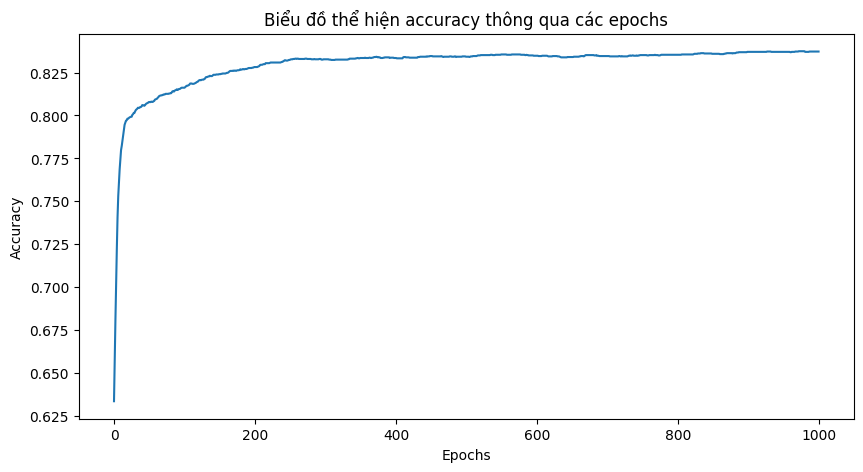

In [746]:
plt.figure(figsize=(10, 5))
plt.plot(softmax_model.acc_his)
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Biểu đồ thể hiện accuracy thông qua các epochs')
plt.show()

#### ***2.5. Visualize loss function by epochs***

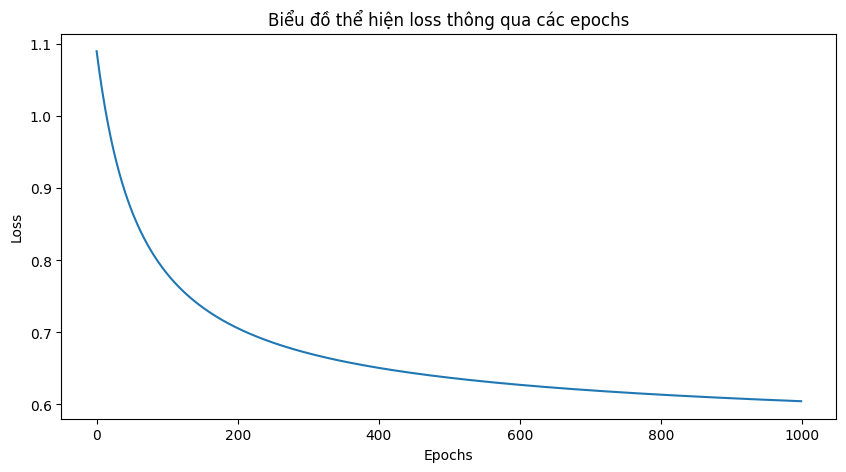

In [747]:
plt.figure(figsize=(10, 5))
plt.plot(softmax_model.loss_his)
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Biểu đồ thể hiện loss thông qua các epochs')
plt.show()

### **3. Assignment 3 (2 scores):**

- Use a Machine Learning library (Scikit Learn or Skorch) to implement and evaluate the Logistic Regression on the [Predict students’ dropout and academic success](https://archive.ics.uci.edu/dataset/697/predict+students+dropout+and+academic+success) dataset.
- Use a Machine Learning library (Scikit Learn or Skorch) to implement and evaluate the Softmax Regression on the [Predict students’ dropout and academic success](https://archive.ics.uci.edu/dataset/697/predict+students+dropout+and+academic+success) dataset.

#### ***3.1. Logistic Regression***

Tạo một `object` có tên là `LogisticRegression` trong thư viện `sklearn.linear_model` với trọng số là `C=0.05` và `max_iter=1000` để giống với phần mô hình được xây bằng numpy trước đó. Sau đó, gọi hàm `fit` đối với `X_train_lr_scaled` và `y_train_lr` để huấn luyện mô hình và hàm `predict` để trả về kết quả dự đoán, lưu trong biến `y_pred_lr`.
Tính `accuracy` bằng cách gọi `accuracy_score` trong thư viện `sklearn.metrics` để đánh giá kết quả mô hình của thư viện `sklearn`.

In [748]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

lr_model = LogisticRegression(C=0.05, max_iter=1000)
lr_model.fit(X_train_lr, y_train_lr)

y_pred_lr = lr_model.predict(X_test_lr)
accuracy_lr_sklearn = accuracy_score(y_test_lr, y_pred_lr)

print(f"Accuracy của Logistic Regression từ thư viện Sklearn: {accuracy_lr_sklearn * 100:.2f}%")

Accuracy của Logistic Regression từ thư viện Sklearn: 82.47%


#### ***3.2. Softmax Regression***

Vì mô hình xây bằng numpy sẽ mã hóa bằng `OneHotEncoding` và tạo ra 3 cột tương ứng với lại số lượng nhãn của cột `Target`, mà trong `Softmax Regression` của thư viện sklearn thì đầu ra sẽ được mã hóa dạng `LabelEncoding` vì thế sẽ chuẩn hóa bằng hàm `label_encoder` được viết trong lớp `preprocessing`. Sau đó, sẽ là bước chia dữ liệu thành `X_train`, `X_test`, `y_train`, `y_test` và chuẩn hóa dữ liệu `X_train` và `X_test` thành `X_train_scaled` và `X_test_scaled`.

In [749]:
train_sklearn, test_sklearn = train.copy(), test.copy()

train_sklearn, mapping = pre.label_encoder(train_sklearn, target_column='Target')
test_sklearn['Target'] = test_sklearn['Target'].map(mapping)

X_train = train_sklearn.iloc[:, :-1].values
y_train = train_sklearn.iloc[:, -1].values

X_test = test_sklearn.iloc[:, :-1].values
y_test = test_sklearn.iloc[:, -1].values

X_train_scaled, mean_train, std_train = pre.scale_features(X_train)
X_test_scaled = (X_test - mean_train) / std_train

Trong thư viện sklearn không có trực tiếp mô hình `Softmax Regression`, tuy nhiên mô hình `Logistic Regression` của sklearn nếu có số lượng nhãn lớn hơn 2 thì sẽ được mặc định là `Softmax Regression`. Vì thế, ta sẽ tạo một object của lớp `LogisticRegression` và thực hiện tương tự như bên trên và sẽ thu được kết quả của mô hình `Softmax Regression`.

In [750]:
sr_model = LogisticRegression(max_iter=1000, C=10.0)
sr_model.fit(X_train_scaled, y_train)

y_pred_sr = sr_model.predict(X_test_scaled)
accuracy_sm_sklearn = accuracy_score(y_test, y_pred_sr)

print(f'Accuracy của mô hình Softmax Regression từ thư viện Sklearn {accuracy_sm_sklearn * 100:.2f}%')

Accuracy của mô hình Softmax Regression từ thư viện Sklearn 75.23%


### **4. Final Review**

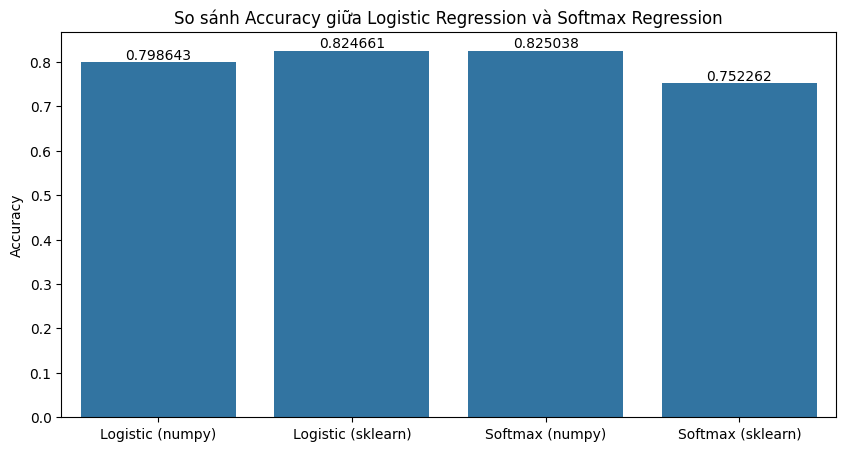

In [751]:
plt.figure(figsize=(10, 5))
bar = sns.barplot(x=['Logistic (numpy)', 'Logistic (sklearn)', 'Softmax (numpy)', 'Softmax (sklearn)'], y=[accuracy_lr, accuracy_lr_sklearn, accuracy_sm, accuracy_sm_sklearn])
plt.ylabel('Accuracy')
plt.title('So sánh Accuracy giữa Logistic Regression và Softmax Regression')
plt.bar_label(bar.containers[0])
plt.show()

Kết quả khi so sánh các mô hình được xây chỉ sử dụng thư viện `numpy` và khi được gọi từ `sklean` khá là tương tự nhau. Cụ thể như sau:
- Đối với mô hình `Logistic Regression`: accuracy của mô hình xây bằng numpy thấp hơn so với khi gọi từ sklearn (0.7986 < 0.8247).

- Đối với mô hình `Softmax Regression`: accuracy của mô hình xây bằng numpy lại có kết quả cao hơn khi gọi bằng sklearn (0.8326 > 0.7523).

Những nguyên nhân có thể ảnh hưởng tới hiệu suất của mô hình:
- Đã loại bỏ những feature category có số quá lớn như là `Course`, `Mother's occupation`, `Father's occupation` và chuẩn hóa dữ liệu theo phân phối chuẩn tắc đối với những dữ liệu dạng continuous.

- Bộ dữ liệu được chia thành `training` và `test` từ ban đầu, sau đó chỉ chuẩn hóa lại nên dữ liệu đối với mỗi mô hình là công bằng.

- Tham số truyền vào của mô hình `softmax` gọi bằng `sklearn` chưa đủ để mô hình đạt hiệu suất cao nhất, đồng thời mô hình này không có sẵn trong `sklearn` nên phải gọi bằng `Logistic Regression` đa lớp.